In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import os.path as op
import yaml
import pandas as pd

In [6]:


def read_all_results_yaml(root_dir, select = ('netmap_config.yaml', 'netmap_config_1.yaml')):
    """
    Reads all YAML files in a directory tree starting from root_dir, processes
    the nested structure (including multiple top-level keys), and concatenates
    the results into a single DataFrame.

    Args:
        root_dir (str): The path to the root directory.
        select (tuple or str): File extension or full filename to select.
                               Defaults to common YAML configuration names.

    Returns:
        pandas.DataFrame: A DataFrame containing the processed data from all YAML files.
                          Returns an empty DataFrame if no files are found or an error occurs.
    """
    all_results_dfs = []

    # Normalize the root_dir path
    root_dir = os.path.abspath(root_dir)

    # Check if the root directory exists
    if not os.path.isdir(root_dir):
        print(f"Error: Directory '{root_dir}' not found.")
        return pd.DataFrame() # Return an empty DataFrame

    if isinstance(select, str):
        select = (select,)

    for dirpath, dirnames, filenames in os.walk(root_dir):
        for filename in filenames:
            # Check if the filename ends with any of the selected strings/extensions
            if any(filename.endswith(s) for s in select):
                filepath = op.join(dirpath, filename)
                print(f"Processing: {filepath}")

                try:
                    with open(filepath, 'r') as f:
                        yaml_content = yaml.safe_load(f)

                    if not yaml_content or not isinstance(yaml_content, dict):
                        continue # Skip empty or invalid YAML file

                    # Iterate through all top-level keys (e.g., netmap_config_1, netmap_config_2, etc.)
                    for config_key, nested_data in yaml_content.items():
                        
                        if not isinstance(nested_data, dict):
                            print(f"Skipping key '{config_key}' in {filename}: not a dictionary.")
                            continue

                        records = []
                        
                        # Extract common metadata for this configuration key
                        clustering_score = nested_data.get('clustering_score')
                        total_number_edges = nested_data.get('total_number_edges')

                        # Iterate through the network-specific keys (like net_53_1113)
                        for net_key, net_data in nested_data.items():
                            
                            # Skip known non-network metadata fields
                            if net_key in ['clustering_score', 'total_number_edges']:
                                continue
                            
                            if not isinstance(net_data, dict):
                                print(f"Skipping network key '{net_key}' under '{config_key}': not a dictionary.")
                                continue

                            # Create a record for the DataFrame
                            record = {
                                'net_name': net_key,           # e.g., net_53_1113
                                'config_key': config_key,      # e.g., netmap_config_1
                                'filename': filename,
                                # Add the common metadata
                                'clustering_score': clustering_score,
                                'total_number_edges': total_number_edges
                            }
                            # Add the network-specific data (edge_overlap, net_size, etc.)
                            record.update(net_data)
                            
                            records.append(record)

                        # Create a DataFrame from the extracted records for this config_key
                        if records:
                            net_dir = op.basename(dirpath)  
                            # The directory one level up is 'CONFIG'
                            config_dir = op.basename(op.dirname(dirpath))
                        


                            overlaps_df = pd.DataFrame(records)
                            # Add the directory name (similar to your original 'net' column)
                            overlaps_df['net_directory'] = op.basename(op.dirname(filepath))
                            overlaps_df['data_config'] = config_dir
                            all_results_dfs.append(overlaps_df)


                except Exception as e:
                    print(f"Error reading or processing {filepath}: {e}")
                    continue

    if all_results_dfs:
        # Concatenate all DataFrames into one
        all_results = pd.concat(all_results_dfs, ignore_index=True)
    else:
        all_results = pd.DataFrame()

    return all_results

In [7]:
df_results = read_all_results_yaml('/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/', select=('clustering_score.json'))


Processing: /data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/config_easy/net_53_11196_net_70_11431_net_84_9903/clustering_score.json
Processing: /data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/config_easy/net_59_10488_net_115_11153_net_84_11226/clustering_score.json
Processing: /data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/config_easy/net_172_10626_net_89_11634_net_76_10367/clustering_score.json
Processing: /data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/config_easy/net_60_10082_net_64_11307_net_84_11226/clustering_score.json
Processing: /data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/config_easy/net_133_10773_net_82_10152_net_72_10551/clustering_score.json
Processing: /data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/config_easy/net_98_11932_net_51_10906_net_60_10082/clustering_score.json
Processing: /data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/config_easy/net_90_11013_net_75_10306_net_

,net_name,config_key,filename,clustering_score,total_number_edges,edge_overlap,net_size,overlap_percent,reverse_overlap_percent,net_directory,data_config
0,net_53_11196,netmap_config_1,clustering_score.json,1.000000,42849,78,78,1.000000,1.000000,net_53_11196_net_70_11431_net_84_9903,config_easy
1,net_70_11431,netmap_config_1,clustering_score.json,1.000000,42849,88,88,1.000000,1.000000,net_53_11196_net_70_11431_net_84_9903,config_easy
2,net_53_11196,netmap_config_2,clustering_score.json,1.000000,42849,78,78,1.000000,1.000000,net_53_11196_net_70_11431_net_84_9903,config_easy
3,net_70_11431,netmap_config_2,clustering_score.json,1.000000,42849,88,88,1.000000,1.000000,net_53_11196_net_70_11431_net_84_9903,config_easy
4,net_53_11196,netmap_config_3,clustering_score.json,1.000000,42849,78,78,1.000000,1.000000,net_53_11196_net_70_11431_net_84_9903,config_easy
...,...,...,...,...,...,...,...,...,...,...,...
927,net_61_10737,netmap_config_9,clustering_score.json,0.967333,104329,132,132,1.000000,1.000000,net_141_11706_net_61_10737_net_70_11670_net_51...,config_three_noise
928,net_70_11670,netmap_config_9,clustering_score.json,0.967333,104329,80,80,1.000000,1.000000,net_141_11706_net_61_10737_net_70_11670_net_51...,config_three_noise
929,net_141_11706,scgenerai_config,clustering_score.json,0.335333,52003,127,175,0.725714,0.725714,net_141_11706_net_61_10737_net_70_11670_net_51...,config_three_noise
930,net_61_10737,scgenerai_config,clustering_score.json,0.335333,52003,80,132,0.606061,0.606061,net_141_11706_net_61_10737_net_70_11670_net_51...,config_three_noise


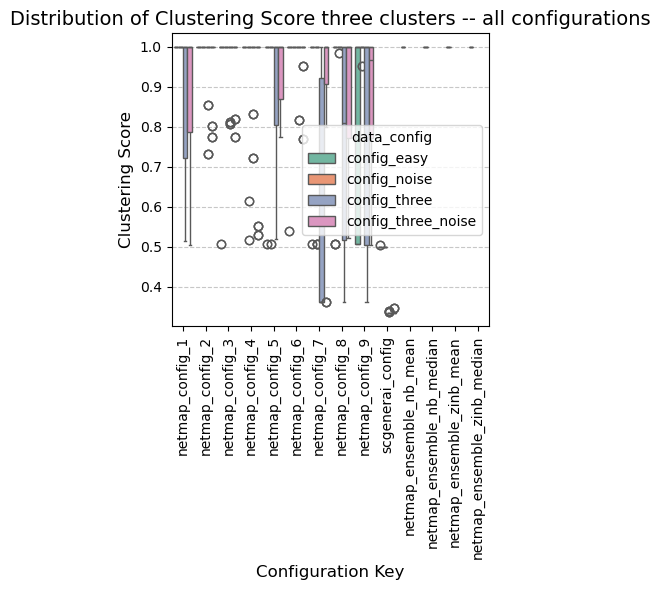

In [11]:
# Define the column to plot on the y-axis
y_col = 'clustering_score'

plt.figure(figsize=(4, 6))

df_results_sub = df_results
sns.boxplot(
    x='config_key',
    y=y_col,
    hue='data_config',
    data=df_results_sub,
    palette='Set2' 
)

plt.title(f'Distribution of {y_col.replace("_", " ").title()} three clusters -- all configurations', fontsize=14)
plt.xlabel('Configuration Key', fontsize=12)
plt.xticks(rotation=90)
plt.ylabel(y_col.replace("_", " ").title(), fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Plot saved to config_overlap_boxplot.png
plt.savefig('config_overlap_boxplot.png')